# Mini Project 1 — Analysis Notebook

**Your name: Sofia Larson**  
**Dataset: Census Data (Tract 63, 2024)**  
**Date: 05/06/2026**  

This notebook has four sections. Work through them in order. Each section has instructions and a code cell to fill in. Add markdown cells to explain your thinking as you go — that writing is part of the assignment.

When you're done, publish this notebook to your GitHub repository and submit the URL to Canvas.

In [1]:
# Setup — run this cell first
# If any package is missing, it will install automatically
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["pandas", "plotly", "kaleido", "nbformat"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)

import pandas as pd
import plotly.express as px

print("Setup complete.")

Installing kaleido...
Setup complete.


---

## Section 1 — Overview

Before writing any code, fill in this section. A good Overview tells anyone reading your notebook — including a future employer — what the analysis is about before they see a single chart.

**Dataset: This data is from the United States Census Bureau for tract 63 in Washington state from the 2024 census, which is represented in the form of various CSVs available at this URL: https://data.census.gov/table/ACSDT5Y2024.B01003?g=1400000US53033006300. **

**Why this dataset: For one of my HCDE projects, I am tasked with redesign the website for the Madison Park community (tract 63), which would heavily benefit from the census data on Madison Park to help inform design decisions that can be more catered to the community.**

**Three analytical questions:**

1. *What age bracket has the highest number of people in the dataset population? (Madison Park, WA)*
2. *What percentage of households have their own children under 18?*
3. *What percent of the population in Madison Park makes over $100K a year in a household, compared to Seattle?*

**What a practitioner would do with these findings: This will be used by UX researchers, for validating/invalidating demographic trends they are observing through research methods that rely on convenience sampling, and by designers who can use these demographics to tweak the design of the redesign to highlight areas of the website that might be more applicable to larger parts of the Madison Park community based on demographics.** 

---

## Section 2 — Data Profile

Load your dataset and get a basic picture of what's in it. Answer these questions in a markdown cell below your code:

- How many rows and columns does your dataset have?
- What does each column represent?
- Are there any obvious data quality issues (missing values, unexpected types, inconsistent formatting)?
- Which column or columns will your analysis focus on, and why?


- The number of columns is between 3-11, and the number of rows is between 1-49.
- Depending on the dataset, each column can represent something different. Typically, it will represent the category being accounted for, the total number of people, and the margin of error.
- Sometimes data may not have representation, like some age brackets having 0 as a count. There is also sometimes multiple different types of data beneath the same column because one type is meant to act as a parent to the others below it. Headers also consist of random syntax, like additional quotation marks.
- My analysis will focus on various categories across the different CSVs, primarily focusing on the people count and its combination with various categories (e.g, Sex, Age, etc.).

In [16]:
# Load your dataset
# Replace 'your_dataset.csv' with your actual filename.
# The file should be in the same folder as this notebook.
# If you're loading from an API result, replace pd.read_csv() with the appropriate call.
#
# Example (app review dataset from class):
# df = pd.read_csv('app_reviews_demo.csv')

df = pd.read_csv('Week6 Assignment/Sex by Age.csv')  # ← replace with your filename

print(df.shape)
df.head()

(49, 3)


,Label (Grouping),Census Tract 63; King County; Washington!!Estimate,Census Tract 63; King County; Washington!!Margin of Error
0,Total:,"6,006",±829
1,Male:,"2,878",±459
2,Under 5 years,30,±27
3,5 to 9 years,215,±120
4,10 to 14 years,130,±61


In [17]:
# Check column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column                                                     Non-Null Count  Dtype 
---  ------                                                     --------------  ----- 
 0   Label (Grouping)                                           49 non-null     object
 1   Census Tract 63; King County; Washington!!Estimate         49 non-null     object
 2   Census Tract 63; King County; Washington!!Margin of Error  49 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


In [18]:
# Summary statistics for numeric columns
df.describe()

,Label (Grouping),Census Tract 63; King County; Washington!!Estimate,Census Tract 63; King County; Washington!!Margin of Error
count,49,49,49
unique,26,42,39
top,5 to 9 years,0,±19
freq,2,6,6


**Your data profile notes:**  
*This highlights that the data needs a lot of cleanup in order to prep it for analysis and visualization. The raw data from the census bureau has headings that aren't intuitive for the columns, some columns and categories are meant to represent a mix of totals, individual counts, age brackets, and the different sexes.*

---

## Section 3 — Analysis

Answer your three research questions using pandas. Each question should have:

1. A markdown cell stating the question
2. A code cell with the analysis
3. A markdown cell with your interpretation — what does the result mean?

You may need to clean or reshape the data before you can answer a question. That's normal — document what you did and why.

**Please note that the code blocks have been reformatted, as my code does the analysis for all three questions by reusing functions shared across the three questions. Therefore, I will be demonstrating my analysis by using a singular code block, and leaving commenhts within the code to make clear what pertains to Question 1, 2, and 3.**

**Question 1:** *What age bracket has the highest number of people in the dataset population? (Madison Park, WA)*

**Interpretation:**  
*This response tells me that most Madison Park residents are between the ages of 50-54 years old, accounting for 10.9% of the population. This result was somewhat expected, as through our research interviews, residents have offhandedly reported anecdotally that Madison Park tends to be a community consisting of older people. However, this census data is far more reliable to make such a claim, as the potential bias from our research, which was based upon convenience and snowball sampling, is not a factor within census data. As for how this will inform the project, this lets us as designers know that when we do redesign the Madison Park website, we should pay design in a way that feels familiar to those who are older and may have less technological experience, and work to factor in accessibility, as impairments affect older populations at a disproportionate rate.*

**Question 2:** *What percentage of households have their own children under 18?*

**Interpretation:**  
*This result tells me that out of the total number of households in Madison Park, 2,710, 29.6% of them have children (of their own) within them. This tells me two things: One, there may be more children than actually presented within the result of this analysis, as the available census data only supported people who had their own children, and not children living with them, and two, that nearly 30% of the households in Madison Park have children with them. This is somewhat expected, as our research indicated that most of our participants had kids and would deliberately attend kid-oriented events in Madison Park. However, having an actual statistic with this helps us as designers realize that even though lots of households have kids, that doesn't necessarily mean that the majority of emphasis on the actual site should be centered around kids, as they tend to be a prominent, but smaller minority.

**Question 3:** *What percent of the population in Madison Park makes over $100K a year in a household, compared to Seattle?*

**Interpretation:**  
*This result tells me that compared to Seattle census data, Madison Park has more residents making over 100k a year, with 22.2% more of the Madison Park population making more than 100k than general Seattle residents. This was somewhat expected, as Madison Park has a reputation for consisting of older, but wealthier, individuals, but this dataset helps confirm this. From a design and research perspective, this lets the designers on our team know that we may want to cater our designs towards wealthier individuals, and perhaps push donating to Friends of Madison Park through our design to meet stakeholder goals.*

In [2]:
# Analysis script that spans across all three questions. Check comments within code to see what parts apply to which questions.

import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd()

# Cleans up the censsus data by converting the data to numeric columns to 
# uniformly format the data for analysis.
def load_clean_census_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.shape[1] < 3:
        # Raises an error if the data does not have at least 3 columns.
        raise ValueError(f"Expected at least 3 columns in {path}, got {df.shape[1]}")

    # Renames the columns to make them more readable.
    df = df.rename(
        # label = category, estimate = value, moe = margin of error
        columns={
            df.columns[0]: "label",
            df.columns[1]: "estimate",
            df.columns[2]: "moe",
        }
    )

    # Removes the non-breaking space and strips the whitespace from the label column.
    df["label"] = (
        df["label"]
        .astype(str)
        .str.replace("\u00a0", " ", regex=False)
        .str.strip()
    )

    df["estimate"] = pd.to_numeric(
        df["estimate"].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )

    df["moe"] = pd.to_numeric(
        df["moe"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("±", "", regex=False)
        .str.strip(),
        errors="coerce",
    )

    return df

def _parse_acs_cell(value) -> float:
    """Parse ACS export cells: counts with commas, (X) suppressed, or percentages like 3.9%."""
    if pd.isna(value):
        return float("nan")
    s = str(value).strip()
    if s in ("(X)", "", "--", "nan"):
        return float("nan")
    s = s.replace(",", "")
    if s.endswith("%"):
        return float(s[:-1])
    s = s.replace("±", "")
    return float(pd.to_numeric(s, errors="coerce"))

# Loads and cleans the households and families data by converting the data
# to numeric columns. This makes the data easier to analyze. Returns a 
# cleaned dataframe.
def load_clean_households_families_csv(path: Path) -> pd.DataFrame:
    """
    Load the wide 'Households and Families' ACS table: one label column plus
    Total / married-couple / male householder / female householder / nonfamily
    estimate + MOE pairs.
    """
    df = pd.read_csv(path)
    col_names = [
        "label",
        "total_estimate",
        "total_moe",
        "married_couple_estimate",
        "married_couple_moe",
        "male_householder_family_estimate",
        "male_householder_family_moe",
        "female_householder_family_estimate",
        "female_householder_family_moe",
        "nonfamily_estimate",
        "nonfamily_moe",
    ]
    if len(df.columns) != len(col_names):
        raise ValueError(
            f"Expected {len(col_names)} columns in {path}, got {len(df.columns)}"
        )
    df.columns = col_names
    # Removes the non-breaking space and strips the whitespace from the label column.
    df["label"] = (
        df["label"]
        .astype(str)
        .str.replace("\u00a0", " ", regex=False)
        .str.strip()
    )
    for c in col_names[1:]:
        df[c] = df[c].map(_parse_acs_cell)
    return df


# Calculates the total population across sexes by age bracket. 
# This function is used to answer question 1.
def population_by_age_bracket(df: pd.DataFrame) -> pd.DataFrame:
    """
    Sum male + female estimates for each age label in a Sex by Age table.
    Skips Total / Male / Female summary rows.
    """
    section = None
    records: list[dict] = []
    for _, row in df.iterrows():
        lab = row["label"]
        if lab == "Male:":
            section = "male"
            continue
        if lab == "Female:":
            section = "female"
            continue
        if lab == "Total:":
            continue
        if section in ("male", "female"):
            records.append(
                {"age_bracket": lab, "estimate": row["estimate"]}
            )
    out = (
        pd.DataFrame(records)
        # Asking what the total population is for each age bracket after
        # combining the male and female populations. This will be used to answer
        # question 1 which determines the age bracket with the largest population, 
        # but also highlights that the data the full picture of population can only
        # be seen by combining the male and female populations.
        .groupby("age_bracket", as_index=False)["estimate"]
        .sum()
        .rename(columns={"estimate": "population"})
    )
    return out


# Loads and cleans the census data on the actual CSV files for analysis.
dfhouseholdincome = load_clean_census_csv(
    DATA_DIR / "Household Income in the Past Year.csv"
)
dfhouseholdincome_seattle = load_clean_census_csv(
    DATA_DIR / "Seattle Household Income for Past Year.csv"
)
dfsexbyage = load_clean_census_csv(DATA_DIR / "Sex by Age.csv")
dftotalpopulation = load_clean_census_csv(DATA_DIR / "Total Population.csv")
dfhouseholdsfamilies = load_clean_households_families_csv(
    DATA_DIR / "Households and Families.csv"
)

# The code below is used to answer the questions for the analysis.
# Question 1: What age bracket has the highest number of people in the
# dataset population? (Madison Park, WA)

# Calculates the total population by age bracket.
age_totals = population_by_age_bracket(dfsexbyage)

# Asking to drop age brackets where combined male+female count is zero. 
# This is used to ensure the data is not skewed by age brackets with no 
# population, and reveals that the data may have missing values in the age brackets.
age_totals_nonzero = age_totals[age_totals["population"] > 0].copy()

# Calculates the total population of the tract.
total_pop = int(dftotalpopulation.loc[0, "estimate"])
idx = age_totals_nonzero["population"].idxmax()
top = age_totals_nonzero.loc[idx]

# Prints the results of the analysis for question 1.
print("Question 1 - What is the age bracket with the largest population in Madison Park?:")
print(f"  Bracket: {top['age_bracket']}")
print(f"  Population: {int(top['population']):,}")
print(
    f"  Share of tract population: {100 * top['population'] / total_pop:.1f}% "
    f"(total population {total_pop:,} from Total Population table)"
)
print()

# Prints the supporting data for question 1.
print(
    "  Supporting data - population by age bracket (Sex by Age; male + female "
    "combined), sorted by population:"
)
age_support = age_totals_nonzero.assign(
    pct_of_tract=lambda x: (100.0 * x["population"] / total_pop).round(1)
).sort_values("population", ascending=False)
print(age_support.to_string(index=False))
print()
print()
print()

# Question 2: What percentage of households have own children under 18?
# Source: Households and Families.csv — row "Households with own children of
# the householder under 18 years" (total households with own children U18) and
# "Total households" for the denominator.

# Checks for null values in the dataframe.
# Asking how many missing values are in each column, which will be used to 
# help flag any large gaps in the data, or where the spreadsheet uses headers
# instead of actual data. 
_ = dfhouseholdsfamilies.isnull().sum()
# Asking for which row labels appear most often, which will be used to verify
# the table structure and ensure the data format is consistent and being read 
# correctly before picking rows by exact labels.
_ = dfhouseholdsfamilies["label"].value_counts().head(10)

# Defines the label for the households with own children of the householder under 18 years.
OWN_CHILDREN_LABEL = (
    "Households with own children of the householder under 18 years"
)

# Asking to filter rows on the total households row to just the rows where
# the total count is greater than zero. This is used to ensure the data is 
# not skewed by households with no total count, and reveals that data may have
# missing values in the total households row.
hh_totals = dfhouseholdsfamilies[
    (dfhouseholdsfamilies["label"] == "Total households")
    & (dfhouseholdsfamilies["total_estimate"] > 0)
]
total_households = int(hh_totals["total_estimate"].iloc[0])

own_children_row = dfhouseholdsfamilies[
    dfhouseholdsfamilies["label"] == OWN_CHILDREN_LABEL
].iloc[0]

# Calculates the total number of households with own children under 18 years.
households_with_own_children_u18 = int(own_children_row["total_estimate"])
pct_hh_with_children = 100 * households_with_own_children_u18 / total_households

# Calculates the total number of households with own children under 18 years by 
# family type (married-couple family, male householder, female householder).
breakdown = pd.DataFrame(
    {
        "family_type": [
            "Married-couple family household",
            "Male householder, no spouse present, family household",
            "Female householder, no spouse present, family household",
        ],
        "households_with_own_children_u18": [
            own_children_row["married_couple_estimate"],
            own_children_row["male_householder_family_estimate"],
            own_children_row["female_householder_family_estimate"],
        ],
    }
)
# Asking to drop rows where the total number of households with own children 
# under 18 is zero. This is used to ensure the data is not skewed by households 
# with no own children under 18, and reveals that data may have missing values 
# in the households with own children under 18 row.
breakdown = breakdown[breakdown["households_with_own_children_u18"] > 0]
breakdown = breakdown.assign(cohort="Own children under 18 (householder)")
# Asking what the total of households with own children under 18 acrosss 
# the different family types is. This highlights that in the data there are
# different family types that have own children under 18 that have to be accounted
# for in the analysis.
by_cohort = breakdown.groupby("cohort", as_index=False)[
    "households_with_own_children_u18"
].sum()

# Prints the results of the analysis for question 2.
print(
    "Question 2 - What percentage of households have own children of the "
    "householder under 18?"
)
print(f"  Households with own children under 18: {households_with_own_children_u18:,}")
print(f"  Total households: {total_households:,}")
print(f"  Percent of households: {pct_hh_with_children:.1f}%")
print()

# Supporting data for question 2.
print("  Supporting data - family-type counts (households with own children under 18):")
print(breakdown.drop(columns=["cohort"]).to_string(index=False))
print()
print("  Supporting data - groupby(cohort) sum check (matches total-with-children count):")
print(by_cohort.to_string(index=False))
print()
print()
print()

# Question 3: Share of households with income over $100K — Madison Park vs Seattle.
# ACS “Household Income in the Past Year” counts households by bracket (not people).
# Brackets strictly above $75k–$99k start at $100k–$124k through $200k+.

INCOME_BRACKETS_100K_PLUS = [
    "$100,000 to $124,999",
    "$125,000 to $149,999",
    "$150,000 to $199,999",
    "$200,000 or more",
]

# Asking to merge the Madison Park and Seattle household income data by the 
# label column. This is used to compare the household income data for the two areas.
madison_brackets = dfhouseholdincome[["label", "estimate"]].rename(
    columns={"estimate": "madison_households"}
)
seattle_brackets = dfhouseholdincome_seattle[["label", "estimate"]].rename(
    columns={"estimate": "seattle_households"}
)
income_compare = madison_brackets.merge(seattle_brackets, on="label", how="outer")
# Keep Census bracket order (merge alone sorts labels alphabetically).
_bracket_order = madison_brackets["label"].tolist()
income_compare = (
    income_compare.set_index("label").reindex(_bracket_order).reset_index(names="label")
)

# Print only rows needed for Q3: total households + income brackets strictly 
# over $100K.
_Q3_ROW_ORDER = ["Total:"] + INCOME_BRACKETS_100K_PLUS
income_compare_for_print = (
    income_compare.set_index("label")
    .loc[_Q3_ROW_ORDER]
    .reset_index(names="label")
)
# Asking to calculate the total number of households in Madison Park and Seattle.
total_mp = float(
    income_compare.loc[income_compare["label"] == "Total:", "madison_households"].iloc[0]
)
total_sea = float(
    income_compare.loc[income_compare["label"] == "Total:", "seattle_households"].iloc[0]
)
high_brackets = income_compare[income_compare["label"].isin(INCOME_BRACKETS_100K_PLUS)]
over_mp = float(high_brackets["madison_households"].sum())
over_sea = float(high_brackets["seattle_households"].sum())
# Calculates the percentage of households in Madison Park and Seattle that make over 
# $100K a year.
q3_summary = pd.DataFrame(
    {
        "area": ["Madison Park (Census Tract 63)", "Seattle city"],
        "total_households": [total_mp, total_sea],
        "households_over_100k": [over_mp, over_sea],
    }
).assign(
    pct_households_over_100k=lambda x: (
        100.0 * x["households_over_100k"] / x["total_households"]
    ).round(1)
)
# Prints the results of the analysis for question 3.
print(
    "Question 3 - What percent of the population in Madison Park makes over "
    "$100K a year in a household, compared to Seattle?"
)
print(
    "  (From ACS household-income brackets: reported as share of households "
    "with income over $100K, not a direct count of people.)"
)
# Prints the summary of the analysis for question 3.
print(q3_summary.to_string(index=False))
print()
mp_pct = float(q3_summary.iloc[0]["pct_households_over_100k"])
sea_pct = float(q3_summary.iloc[1]["pct_households_over_100k"])
print(f"  Madison Park (share of households): {mp_pct:.1f}%")
print(f"  Seattle (share of households):      {sea_pct:.1f}%")
print(f"  Difference (Madison Park - Seattle): {mp_pct - sea_pct:+.1f} percentage points")
print()

# Supporting data for question 3.
print(
    "  Supporting data - household income (total and brackets over $100K, "
    "Madison Park vs Seattle):"
)
print(income_compare_for_print.to_string(index=False))
print()

Question 1 - What is the age bracket with the largest population in Madison Park?:
  Bracket: 50 to 54 years
  Population: 655
  Share of tract population: 10.9% (total population 6,006 from Total Population table)

  Supporting data - population by age bracket (Sex by Age; male + female combined), sorted by population:
      age_bracket  population  pct_of_tract
   50 to 54 years         655          10.9
   35 to 39 years         530           8.8
   15 to 17 years         449           7.5
   30 to 34 years         442           7.4
     5 to 9 years         398           6.6
   40 to 44 years         387           6.4
   70 to 74 years         361           6.0
   55 to 59 years         334           5.6
   45 to 49 years         305           5.1
   10 to 14 years         266           4.4
   22 to 24 years         259           4.3
   75 to 79 years         248           4.1
   25 to 29 years         239           4.0
  60 and 61 years         203           3.4
85 years and over 

---

## Section 4 — Visualization

Create at least one visualization that supports one of your analysis findings. Your chart should:

- Have a title that states the finding, not just the data (e.g., "Satisfaction scores drop sharply after age 40" not "Satisfaction by age")
- Have labeled axes
- Use a chart type appropriate for your data (bar for categorical comparison, scatter for relationships, line for trends over time)

Below the chart, explain in a markdown cell: why you chose this chart type, and what you want the reader to take away from it.

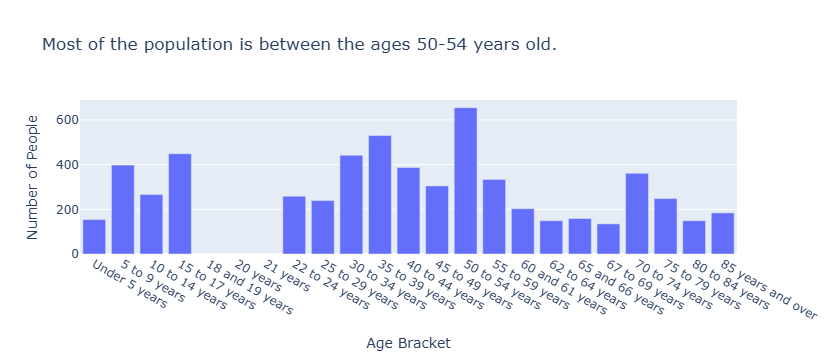

In [20]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("Week6 Assignment/Sex by Age.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Label (Grouping)": "Age Ranges",
    "Census Tract 63; King County; Washington!!Estimate": "Number of People"
})

summary_rows = ["Total:", "Male:", "Female:"]
df = df[~df["Age Ranges"].str.strip().isin(summary_rows)].copy()
df["Age Ranges"] = df["Age Ranges"].str.strip()

# Remove commas and convert to numeric
df["Number of People"] = pd.to_numeric(
    df["Number of People"].str.replace(",", ""), errors="coerce"
)

df = df.dropna(subset=["Number of People"])

# Combine Male + Female into one total per age bracket
df_total = df.groupby("Age Ranges", sort=False)["Number of People"].sum().reset_index()

fig = px.bar(
    df_total,
    x="Age Ranges",
    y="Number of People",
    title="Most of the population is between the ages 50-54 years old.",
    labels={"Age Ranges": "Age Bracket", "Number of People": "Number of People"}
)
fig.show()

**Chart rationale:**  
*I opted for a bar chart since I wanted to compare the number of people in the various age brackets of Madison Park against each other to help understand what age brackets might be more represented within the population. This data consists of only one variable, and is fairly static since the data comes from the 2024 Census data, which meant a bar chart might be best suited for this visualization.*

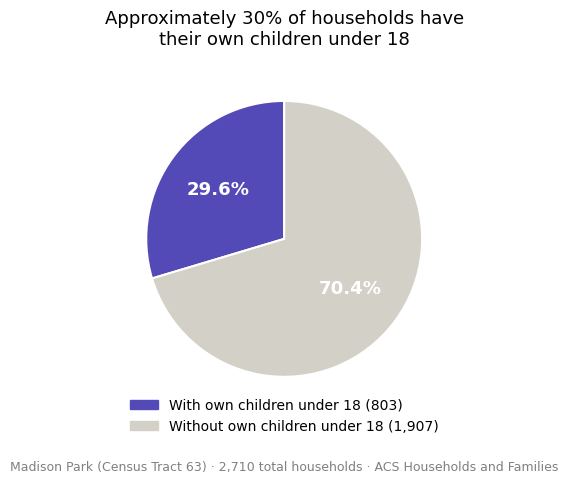

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = ["With own children under 18", "Without own children under 18"]
sizes  = [pct_hh_with_children, 100 - pct_hh_with_children]
colors = ["#534AB7", "#D3D1C7"]

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"},
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight("bold")
    t.set_color("white")

ax.set_title(
    "Approximately 30% of households have\ntheir own children under 18",
    fontsize=13,
    fontweight="medium",
    pad=16,
)
legend_patches = [
    mpatches.Patch(color=c, label=f"{l} ({v:,})")
    for c, l, v in zip(
        colors, labels,
        [households_with_own_children_u18, total_households - households_with_own_children_u18]
    )
]
ax.legend(handles=legend_patches, loc="lower center", bbox_to_anchor=(0.5, -0.1),
          fontsize=10, frameon=False)
ax.text(
    0, -1.65,
    f"Madison Park (Census Tract 63) · {total_households:,} total households · ACS Households and Families",
    ha="center", va="center", fontsize=9, color="gray"
)

plt.tight_layout()
plt.show()


**Chart rationale:**  
*I opted for a pie chart because I wanted to see a breakdown of only a few options that comprise the entire population of Madison Park. I specifically also wanted to see a percentage breakdown; therefore, a pie chart was best suited, as it represents the sum of parts while also providing a little information about the percentage of each part (as opposed to a bar graph, for example).*

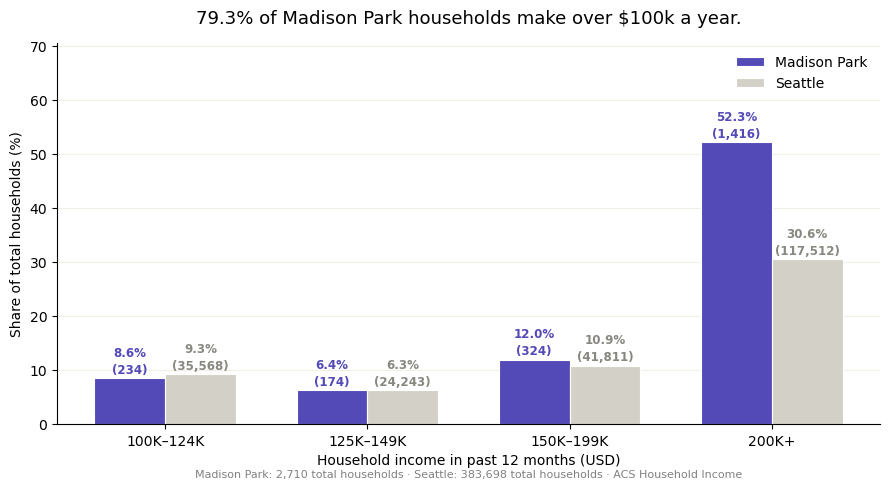

In [13]:
import matplotlib.pyplot as plt
import numpy as np

brackets_100k_plus = [
    "$100,000 to $124,999",
    "$125,000 to $149,999",
    "$150,000 to $199,999",
    "$200,000 or more",
]
short_labels = ["100K–124K", "125K–149K", "150K–199K", "200K+"]

mask = income_compare["label"].isin(brackets_100k_plus)
plot_df = income_compare[mask].copy()
plot_df["madison_pct"] = (plot_df["madison_households"] / total_mp * 100).round(1)
plot_df["seattle_pct"] = (plot_df["seattle_households"] / total_sea * 100).round(1)

x = np.arange(len(short_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_mp  = ax.bar(x - width/2, plot_df["madison_pct"].values, width,
                  label="Madison Park", color="#534AB7", edgecolor="white", linewidth=0.8)
bars_sea = ax.bar(x + width/2, plot_df["seattle_pct"].values, width,
                  label="Seattle", color="#D3D1C7", edgecolor="white", linewidth=0.8)

for bar, pct, count in zip(bars_mp, plot_df["madison_pct"], plot_df["madison_households"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{pct}%\n({int(count):,})", ha="center", va="bottom",
            fontsize=8.5, color="#534AB7", fontweight="bold", linespacing=1.4)

for bar, pct, count in zip(bars_sea, plot_df["seattle_pct"], plot_df["seattle_households"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{pct}%\n({int(count):,})", ha="center", va="bottom",
            fontsize=8.5, color="#888780", fontweight="bold", linespacing=1.4)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_xlabel("Household income in past 12 months (USD)", fontsize=10)
ax.set_ylabel("Share of total households (%)", fontsize=10)
ax.set_title(
    "79.3% of Madison Park households make over $100k a year.",
    fontsize=13, fontweight="medium", pad=14
)
ax.legend(fontsize=10, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, plot_df[["madison_pct", "seattle_pct"]].values.max() * 1.35)
ax.yaxis.grid(True, color="#F1EFE8", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.text(
    0.5, -0.13,
    f"Madison Park: {total_mp:,.0f} total households · Seattle: {total_sea:,.0f} total households · ACS Household Income",
    ha="center", va="center", fontsize=8, color="gray", transform=ax.transAxes
)

plt.tight_layout()
plt.show()

**Chart rationale:**  
*I chose this chart because it allows for a static comparison of two different variables, which are the location (Seattle vs Madison Park) and the income bracket. Though I could have represented the data to answer the question by just representing the 100k-124k bracket by using a pie chart, in this case, its also very valuable to know in which income brackets most residents are part of (unlike the previous question, where a further breakdown of kids' ages wouldn't be extremely applicable to our research). From this breakdown, we can see that the reason Madison Park has a higher percentage of households making over 100k, its because in Madison park, there is approximately 22% more of their population making over 200k in comparison to Seattle. The other income brackets in comparison do not have such a stark percentage of the population difference between Madison Park and Seattle.*

---

## Section 5 — Conclusions

Write 3–5 sentences summarizing what you found. Address these questions:

- What is the most important thing your analysis revealed?
- What surprised you?
- What would you investigate next if you had more time or data?
- What are the limitations of this analysis — what can't you conclude from this data?

Then complete the competency claim below.

**Summary of findings:**  
*The most important thing my analysis revealed was that Madison Park residents are wealthier than I had anticipated, with over 50% of the households making more than $200K, which indicates that for our website redesign, emphasizing design to try and convert residents to future donors will be pivotal, as those who make more tend to have the extra change to spare for donations. This was also the most surprising part of this analysis, as I knew at a glance that 70% of residents made more than 100k a year, but did not realize that such a large majority of that percentage was in the 200k-plus bracket. If I had more data, I would have liked to investigate question two a bit further and discover what percentages of households in Madison Park had kids at all, for the only census data I could locate on households with children were for families who had their own children in their households. I feel as if having access to that data would have painted a more accurate representation of how many of the families in Madison Park may be more interested in kid-oriented events, but, with that lack of data, this is considered a limitation.

---

## Competency Claim

In a `mp1.md` file in your GitHub repository, write a short competency claim (2–4 sentences) for each domain you feel this project demonstrates. Be specific — cite something you actually did in this notebook.

Domains covered by this project typically include:
- **C3 — Data cleaning and file handling** (if you cleaned or reshaped data)
- **C5 — Data analysis with pandas** (answering questions with code)
- **C6 — Data visualization** (your chart)
- **C7 — Critical evaluation and professional judgment** (your interpretation and limitations section)

You don't have to claim every domain — only the ones your work actually demonstrates.